In [1]:
# ============================================================
# NOTEBOOK 03 — Experimentos A/B con MLflow
# Ejecuta el baseline + 3 variantes y genera la tabla comparativa
# ============================================================

# Experimentos A/B — Baseline vs. 3 variantes

Objetivo: cuantificar el impacto de tres decisiones de diseño respecto al baseline:
- Var A: feature set (solo temporal vs. temporal+espectral)
- Var B: clasificador (RF vs. SVM-RBF)
- Var C: ventana (200 ms vs. 400 ms — opcional, requiere re-ingesta)

In [2]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [3]:
import yaml
import warnings
warnings.filterwarnings("ignore")

with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

from posture_risk.experiments.runner import run_variant, VARIANTS
from posture_risk.experiments.compare import (
    load_all_results, build_comparison_table,
    print_markdown_table, plot_pr_curves
)

print(f"\nVariantes disponibles:")
for k, v in VARIANTS.items():
    print(f"  • {k:30s} — {v['name']}")


Variantes disponibles:
  • baseline                       — Baseline RF (temporal+espectral)
  • var_a_only_temporal            — Var A — Solo features temporales
  • var_b_svm_linear               — Var B — SVM Lineal


## 1. Ejecutar Baseline + Variantes A y B

**Nota:** Var C (ventana 400 ms) requiere re-ejecutar el pipeline de ingesta.
Se omite aquí por costo y se documenta en el reporte como trabajo futuro.

In [5]:
results_run = {}
for variant_key in ["baseline", "var_a_only_temporal", "var_b_svm_linear"]:
    results_run[variant_key] = run_variant(variant_key, cfg)

2026-05-22 13:14:32.192 | INFO     | posture_risk.experiments.runner:run_variant:217 - ======================================================================
2026-05-22 13:14:32.193 | INFO     | posture_risk.experiments.runner:run_variant:218 - VARIANTE: Baseline RF (temporal+espectral)
2026-05-22 13:14:32.194 | INFO     | posture_risk.experiments.runner:run_variant:219 -   Random Forest con features temporales + espectrales, ventana 200 ms
2026-05-22 13:14:32.195 | INFO     | posture_risk.experiments.runner:run_variant:220 - ======================================================================
2026-05-22 13:14:33.406 | INFO     | posture_risk.experiments.runner:run_variant:227 -   X shape: (194205, 297)  (all)
2026-05-22 13:14:33.410 | INFO     | posture_risk.experiments.runner:run_variant:228 -   y shape: (194205,)  | clases: (array([0, 1, 2], dtype=int32), array([80613, 67278, 46314]))
LOSO [rf]: 100%|█████████████████████████████████████████████████████████████████████████| 9/9 [1

## 2. Cargar resultados consolidados

In [6]:
experiments_dir = Path(cfg["paths"]["figures"]).parent / "experiments"
results = load_all_results(experiments_dir)
print(f"Resultados cargados: {list(results.keys())}")

2026-05-22 14:47:36.713 | INFO     | posture_risk.experiments.compare:load_all_results:63 - Variantes cargadas: ['baseline', 'var_a_only_temporal', 'var_b_svm_linear']


Resultados cargados: ['baseline', 'var_a_only_temporal', 'var_b_svm_linear']


## 3. Tabla comparativa estándar

In [7]:
df_comparison = build_comparison_table(results)
print_markdown_table(df_comparison, output_path=experiments_dir / "comparison_table.md")
df_comparison.to_csv(experiments_dir / "comparison_table.csv", index=False)
df_comparison

2026-05-22 14:47:41.316 | INFO     | posture_risk.experiments.compare:print_markdown_table:104 - Tabla guardada en reports\experiments\comparison_table.md



| Modelo                           | F1-Macro ★      | Accuracy        | AUC-OvR         | AP-Macro        |   Tiempo (s) |
|:---------------------------------|:----------------|:----------------|:----------------|:----------------|-------------:|
| Baseline RF (temporal+espectral) | 0.7942 ± 0.2003 | 0.8325 ± 0.1088 | 0.9661 ± 0.0079 | 0.8697 ± 0.1903 |        858.4 |
| Var A — Solo features temporales | 0.7955 ± 0.2004 | 0.8348 ± 0.1077 | 0.9664 ± 0.0086 | 0.8703 ± 0.1906 |        600.4 |
| Var B — SVM Lineal               | 0.7599 ± 0.2037 | 0.7918 ± 0.1428 | 0.9487 ± 0.0117 | 0.8378 ± 0.1801 |       3953.4 |



,Modelo,F1-Macro ★,Accuracy,AUC-OvR,AP-Macro,Tiempo (s),Variante
0,Baseline RF (temporal+espectral),0.7942 ± 0.2003,0.8325 ± 0.1088,0.9661 ± 0.0079,0.8697 ± 0.1903,858.4,baseline
1,Var A — Solo features temporales,0.7955 ± 0.2004,0.8348 ± 0.1077,0.9664 ± 0.0086,0.8703 ± 0.1906,600.4,var_a_only_temporal
2,Var B — SVM Lineal,0.7599 ± 0.2037,0.7918 ± 0.1428,0.9487 ± 0.0117,0.8378 ± 0.1801,3953.4,var_b_svm_linear


## 4. Gráfico clave — Curva Precision-Recall comparativa

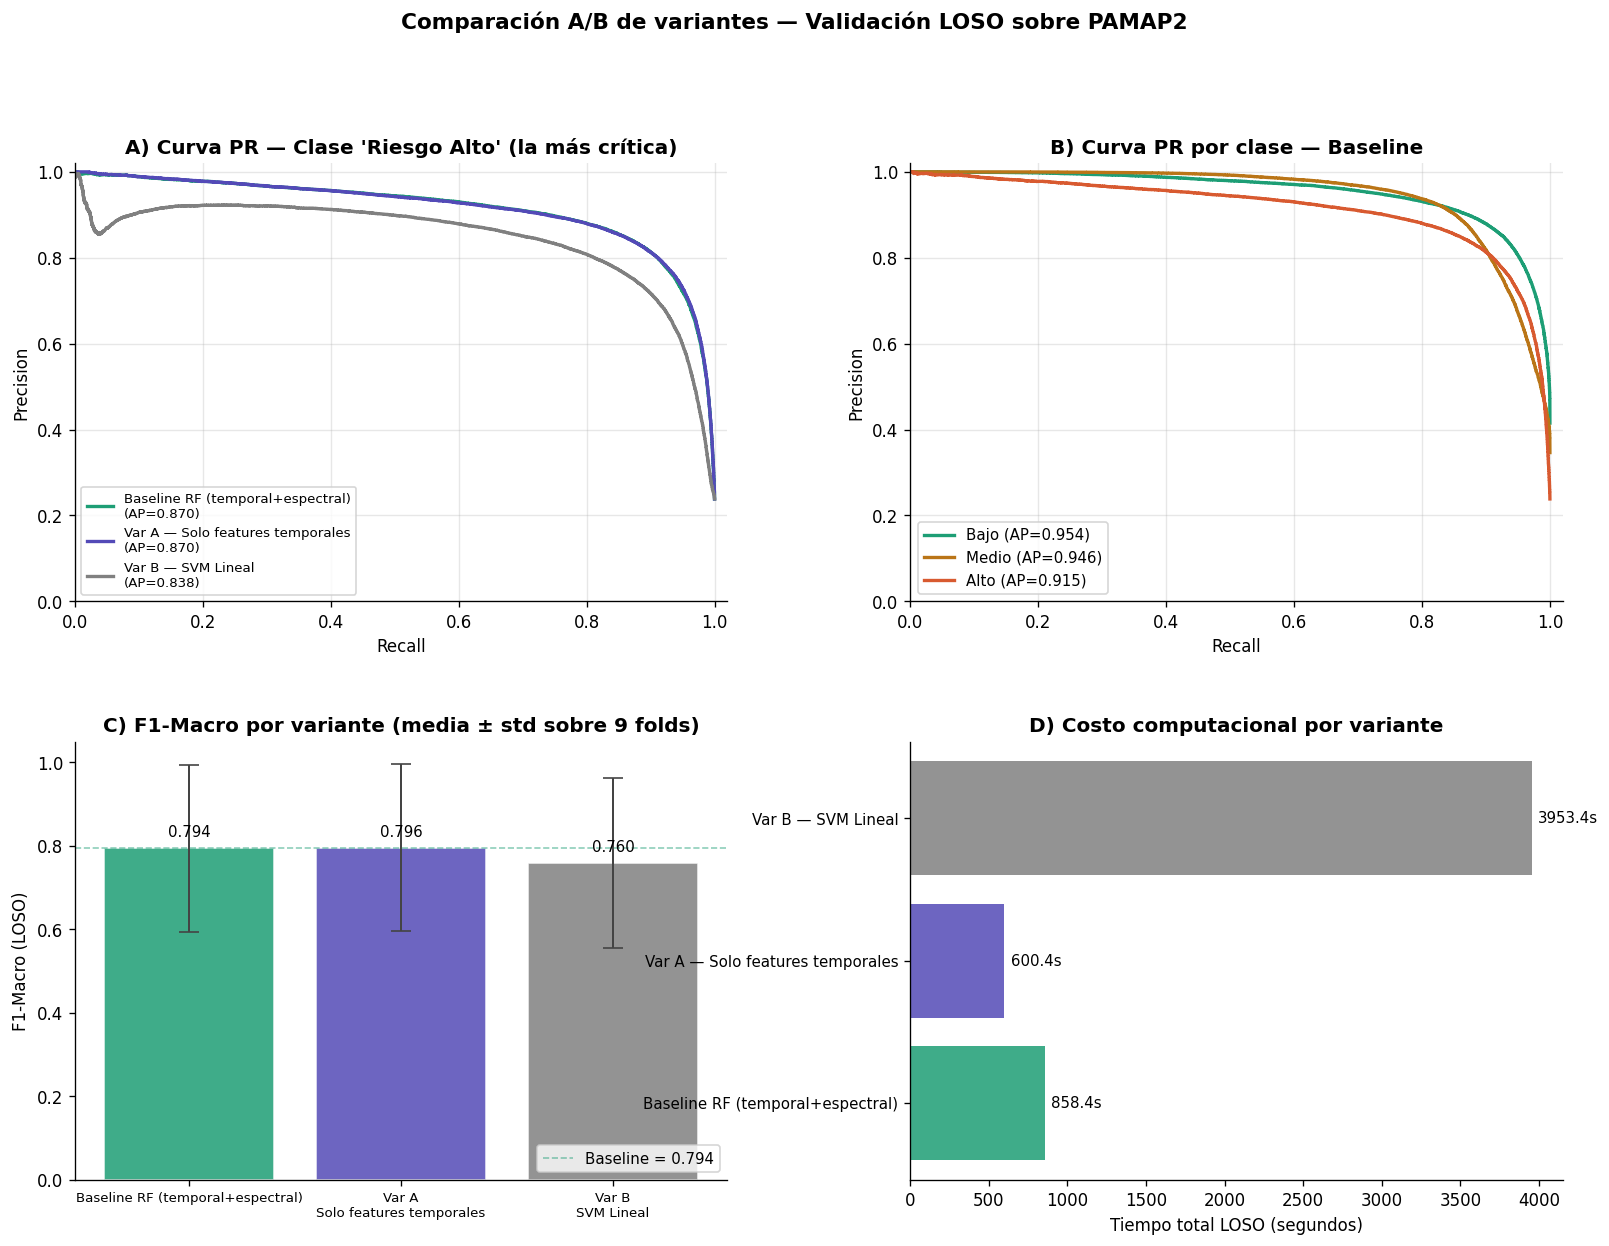

2026-05-22 14:47:52.735 | INFO     | posture_risk.experiments.compare:plot_pr_curves:217 - Figura guardada en reports\figures\experiments_comparison.png


In [8]:
figures_dir = Path(cfg["paths"]["figures"])
plot_pr_curves(results, output_path=figures_dir / "experiments_comparison.png")

## 5. Conclusiones del experimento

**Hallazgos principales:**
1. ¿La métrica principal (F1-Macro) cambia significativamente entre variantes?
2. ¿Var A pierde mucho rendimiento al eliminar features espectrales?
   → Si la pérdida es < 0.02, podría considerarse omitir FFT en producción.
3. ¿Var B (SVM-RBF) supera al baseline?
   → Si no lo hace, justifica usar RF que es más rápido y interpretable.
4. ¿El costo computacional escala razonablemente con la complejidad?

In [9]:
print("\nResumen ejecutivo:")
for v_key, data in results.items():
    s = data["summary"]
    print(f"  {data['name']}")
    print(f"    F1-Macro: {s['f1_macro_mean']:.4f} ± {s['f1_macro_std']:.4f}")
    print(f"    Tiempo:   {s['total_time_s']:.1f}s")
    print()

# Confirmación de zero leakage
print("✓ Zero leakage confirmado: assertion explícita en cada fold de runner.py")
print("✓ Split por grupo (LOSO): sujetos disjuntos entre train y test")
print("✓ StandardScaler.fit ejecutado SOLO en train de cada fold")


Resumen ejecutivo:
  Baseline RF (temporal+espectral)
    F1-Macro: 0.7942 ± 0.2003
    Tiempo:   858.4s

  Var A — Solo features temporales
    F1-Macro: 0.7955 ± 0.2004
    Tiempo:   600.4s

  Var B — SVM Lineal
    F1-Macro: 0.7599 ± 0.2037
    Tiempo:   3953.4s

✓ Zero leakage confirmado: assertion explícita en cada fold de runner.py
✓ Split por grupo (LOSO): sujetos disjuntos entre train y test
✓ StandardScaler.fit ejecutado SOLO en train de cada fold
